<a href="https://colab.research.google.com/github/tameralqadi/Project-ML/blob/main/Copy_of_ML_Project_(Tamer%2CMarwan).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Results:
✅ Accuracy (R2 Score): 91.56%
📉 Mean Error (MAE) in Rupees: ₹4914.93
📉 Mean Error (MAE) in Dollars: $59.22


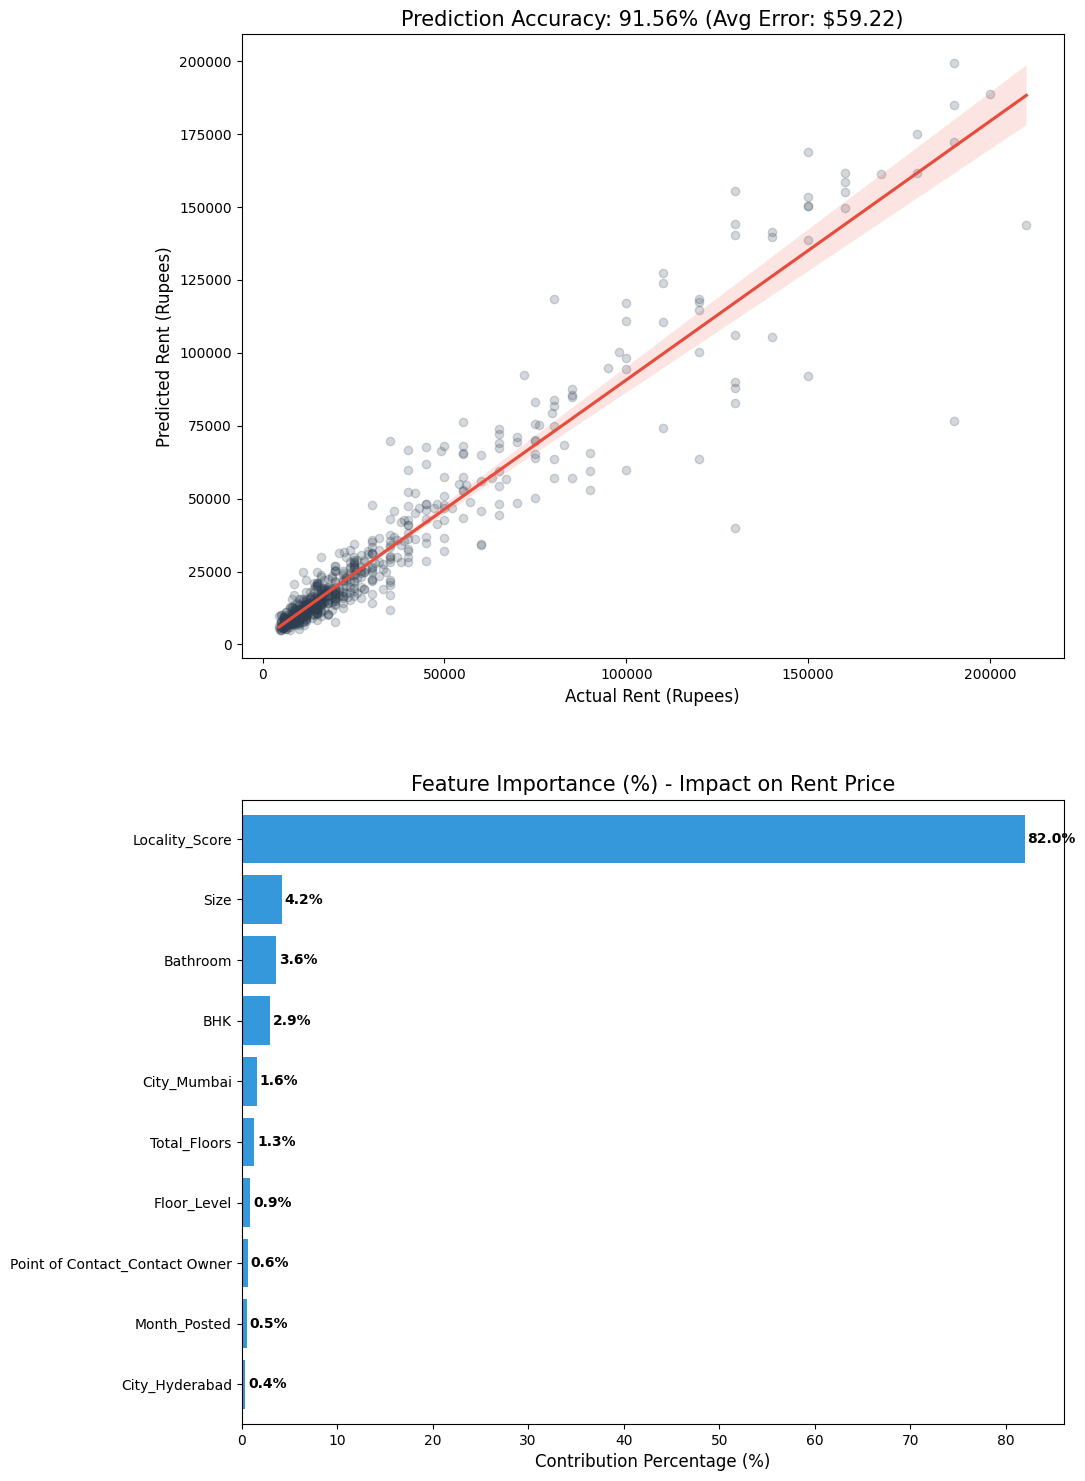

In [ ]:
# Tamer AL-Qadi 221143
# Marwan AL-Sarsour 221045

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. تحميل البيانات
df = pd.read_csv('House_Rent_Dataset.csv')

# 2. هندسة كافة الميزات (بدون استثناء أي عامل)
df['Posted On'] = pd.to_datetime(df['Posted On'])
df['Month_Posted'] = df['Posted On'].dt.month

# الموقع: تحويله لوزن رقمي (Target Encoding)
locality_map = df.groupby('Area Locality')['Rent'].mean()
df['Locality_Score'] = df['Area Locality'].map(locality_map)

# الطابق: استخراج رقم الطابق وإجمالي الأدوار
def split_floor(floor_str):
    parts = str(floor_str).split(' out of ')
    level = parts[0].strip()
    total = parts[1].strip() if len(parts) > 1 else "1"
    if 'Ground' in level: level_num = 0
    elif 'Basement' in level: level_num = -1
    else:
        try: level_num = int(level.split()[0])
        except: level_num = 0
    try: total_num = int(total)
    except: total_num = 1
    return level_num, total_num

df[['Floor_Level', 'Total_Floors']] = df['Floor'].apply(lambda x: pd.Series(split_floor(x)))

# 3. تنظيف البيانات (حذف المتطرفين لتقليل الخطأ)
q_low, q_high = df['Rent'].quantile([0.01, 0.98])
df = df[(df['Rent'] > q_low) & (df['Rent'] < q_high)].copy()
df['Rent_Log'] = np.log1p(df['Rent'])

# 4. التجهيز النهائي للمصفوفة X
X = df.drop(['Rent', 'Rent_Log', 'Floor', 'Area Locality', 'Posted On'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['Rent_Log']

# 5. تدريب الموديل بأقوى إعدادات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
model = RandomForestRegressor(n_estimators=600, max_depth=30, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. التوقعات
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# 7. الحسابات المالية (الروبية والدولار)
r2_final = r2_score(y_test, y_pred_log) * 100
mae_rupees = mean_absolute_error(y_actual, y_pred)
mae_dollars = mae_rupees / 83  # سعر الصرف التقريبي

# 8. طباعة النتائج النهائية بشكل منسق
print("Final Results:")
print(f"✅ Accuracy (R2 Score): {r2_final:.2f}%")
print(f"📉 Mean Error (MAE) in Rupees: ₹{mae_rupees:.2f}")
print(f"📉 Mean Error (MAE) in Dollars: ${mae_dollars:.2f}")


# 9. الرسم البياني المحسن
plt.figure(figsize=(12, 16))

# الرسم الأول: دقة التوقع (مع إضافة قيمة الخطأ بالدولار في العنوان)
plt.subplot(2, 1, 1)
sns.regplot(x=y_actual, y=y_pred, scatter_kws={'alpha':0.2, 'color':'#2c3e50'}, line_kws={'color':'#e74c3c'})
plt.title(f'Prediction Accuracy: {r2_final:.2f}% (Avg Error: ${mae_dollars:.2f})', fontsize=15)
plt.xlabel('Actual Rent (Rupees)', fontsize=12)
plt.ylabel('Predicted Rent (Rupees)', fontsize=12)

# الرسم الثاني: أهمية العوامل بالنسبة المئوية واضحة
plt.subplot(2, 1, 2)
importances = model.feature_importances_ * 100
feat_importances = pd.Series(importances, index=X.columns).sort_values().tail(10)

ax = feat_importances.plot(kind='barh', color='#3498db', width=0.8)
plt.title('Feature Importance (%) - Impact on Rent Price', fontsize=15)
plt.xlabel('Contribution Percentage (%)', fontsize=12)

# إضافة النسب المئوية بجانب كل عمود
for i, v in enumerate(feat_importances):
    ax.text(v + 0.3, i, f'{v:.1f}%', color='black', fontweight='bold', va='center')

plt.tight_layout(pad=5.0)
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

# تحميل البيانات
data = pd.read_csv("House_Rent_Dataset.csv")  # استبدل المسار بالمسار الفعلي للملف

# استعراض البيانات
print(data.head())

# تحويل الأعمدة الزمنية إلى خصائص (مثل السنة، الشهر، اليوم)
data['Year'] = pd.to_datetime(data['Posted On']).dt.year
data['Month'] = pd.to_datetime(data['Posted On']).dt.month
data['Day'] = pd.to_datetime(data['Posted On']).dt.day
data = data.drop('Posted On', axis=1)  # حذف العمود الأصلي بعد تحويله

# تنظيف البيانات (إزالة القيم المفقودة)
data = data.dropna()

# تحويل عمود "Floor" إلى قيمة عددية فقط (الفصل بين الرقمين)
def extract_floor(floor_value):
    try:
        return int(floor_value.split(' ')[0])  # استخراج الرقم قبل "out of"
    except:
        return np.nan  # في حالة وجود قيم غير متوقعة، إرجاع NaN

data['Floor'] = data['Floor'].apply(extract_floor)

# فصل البيانات إلى متغيرات مستقلة (X) و متغير الهدف (y)
X = data.drop('Rent', axis=1)  # استبدال 'Rent' باسم العمود الذي يحتوي على المتغير الهدف
y = data['Rent']

# تحويل الأعمدة الفئوية باستخدام One-Hot Encoding
cat_features = ['Area Type', 'Furnishing Status', 'Tenant Preferred', 'Area Locality', 'City', 'Point of Contact']
X = pd.get_dummies(X, columns=cat_features)

# تحويل المتغير الهدف (Rent) باستخدام log transformation لتقليل تأثير القيم الكبيرة
y = np.log1p(y)

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إعداد المعلمات المحتملة للبحث العشوائي
param_dist = {
    'learning_rate': [0.01, 0.05],
    'max_depth': [6, 8, 10],
    'n_estimators': [500, 1000],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
}

# بناء نموذج XGBoost
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# استخدام RandomizedSearchCV للبحث عن أفضل المعلمات
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=5, cv=3, verbose=2, n_jobs=-1, random_state=42, scoring='neg_mean_squared_error')

# تدريب النموذج باستخدام RandomizedSearchCV
random_search.fit(X_train, y_train)

# عرض أفضل المعلمات
print(f"Best parameters found: {random_search.best_params_}")

# استخدام النموذج الأفضل للتنبؤ
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# حساب المقاييس
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# عرض المقاييس
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

# حساب النسبة المئوية للأداء:
# RMSE كنسبة مئوية (تقاس كنسبة من متوسط القيم الفعلية)
rmse_percentage = (rmse / y_test.mean()) * 100
print(f'Root Mean Squared Error (RMSE) as Percentage: {rmse_percentage:.2f}%')

# R-squared كنسبة مئوية: (R² * 100) لنظهرها كنسبة مئوية
r2_percentage = r2 * 100
print(f'R-squared (R²) as Percentage: {r2_percentage:.2f}%')

# حساب النسبة المئوية للأخطاء (Mean Absolute Error over the Mean of y_test)
mae = np.mean(np.abs(y_pred - y_test))
mae_percentage = (mae / y_test.mean()) * 100
print(f'Mean Absolute Error (MAE) as Percentage: {mae_percentage:.2f}%')

# رسم التنبؤات مقابل القيم الحقيقية
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Prediction Line')
plt.title('Predictions vs Actuals')
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')

# إضافة المفتاح (Legend) للتوضيح
plt.legend()

plt.show()

# حساب الأخطاء (الفروق بين القيم الحقيقية والتنبؤات)
errors = y_test - y_pred

# رسم توزيع الأخطاء
plt.figure(figsize=(8,6))
plt.hist(errors, bins=20, color='orange', edgecolor='black', label='Residuals (Errors)')
plt.title('Residuals Distribution')
plt.xlabel('Residuals (Errors)')
plt.ylabel('Frequency')

# إضافة المفتاح (Legend) للتوضيح
plt.legend()

plt.show()
